## Decision Tree Regressor (Diabetes Dataset)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
from sklearn.datasets import load_diabetes

In [3]:
diabetes = load_diabetes()

In [4]:
diabetes

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]], shape=(442, 10)),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142.

In [5]:
diabetes['DESCR']

'.. _diabetes_dataset:\n\nDiabetes dataset\n----------------\n\nTen baseline variables, age, sex, body mass index, average blood\npressure, and six blood serum measurements were obtained for each of n =\n442 diabetes patients, as well as the response of interest, a\nquantitative measure of disease progression one year after baseline.\n\n**Data Set Characteristics:**\n\n:Number of Instances: 442\n\n:Number of Attributes: First 10 columns are numeric predictive values\n\n:Target: Column 11 is a quantitative measure of disease progression one year after baseline\n\n:Attribute Information:\n    - age     age in years\n    - sex\n    - bmi     body mass index\n    - bp      average blood pressure\n    - s1      tc, total serum cholesterol\n    - s2      ldl, low-density lipoproteins\n    - s3      hdl, high-density lipoproteins\n    - s4      tch, total cholesterol / HDL\n    - s5      ltg, possibly log of serum triglycerides level\n    - s6      glu, blood sugar level\n\nNote: Each of thes

In [8]:
pd.DataFrame(diabetes.data, columns = ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']).head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [9]:
diabetes.target

array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
        68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
        87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
       259.,  53., 190., 142.,  75., 142., 155., 225.,  59., 104., 182.,
       128.,  52.,  37., 170., 170.,  61., 144.,  52., 128.,  71., 163.,
       150.,  97., 160., 178.,  48., 270., 202., 111.,  85.,  42., 170.,
       200., 252., 113., 143.,  51.,  52., 210.,  65., 141.,  55., 134.,
        42., 111.,  98., 164.,  48.,  96.,  90., 162., 150., 279.,  92.,
        83., 128., 102., 302., 198.,  95.,  53., 134., 144., 232.,  81.,
       104.,  59., 246., 297., 258., 229., 275., 281., 179., 200., 200.,
       173., 180.,  84., 121., 161.,  99., 109., 115., 268., 274., 158.,
       107.,  83., 103., 272.,  85., 280., 336., 281., 118., 317., 235.,
        60., 174., 259., 178., 128.,  96., 126., 28

In [10]:
# dependant and independant features
x = pd.DataFrame(diabetes.data, columns = ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'])
y = diabetes.target

In [11]:
# train test split

from sklearn.model_selection import train_test_split

In [12]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [13]:
from sklearn.tree import DecisionTreeRegressor

In [14]:
tree_regressor = DecisionTreeRegressor()

In [15]:
tree_regressor.fit(x_train, y_train)

DecisionTreeRegressor()

In [16]:
y_pred = tree_regressor.predict(x_test)

In [17]:
# calculate the score

from sklearn.metrics import r2_score

In [18]:
print(r2_score(y_test, y_pred))

-0.04907893445991096


## Hyperparameter Tuning

In [19]:
params = {
    'max_depth': [1, 2, 3, 4, 5, 10, 15, 20, 25],
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
    'splitter': ['best', 'random'],
    'max_features': ['auto', 'sqrt', 'log2']
}

In [20]:
from sklearn.model_selection import GridSearchCV

In [21]:
grid = GridSearchCV(estimator=DecisionTreeRegressor(), param_grid=params, cv=5, scoring='r2')

In [22]:
grid.fit(x_train, y_train)

d:\DS, ML, DL, NLP\Machine Learning\venv\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
360 fits failed out of a total of 1080.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
360 fits failed with the following error:
Traceback (most recent call last):
  File "d:\DS, ML, DL, NLP\Machine Learning\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\DS, ML, DL, NLP\Machine Learning\venv\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "d:\DS, ML, DL, NLP\Machine Learning\venv\Li

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['squared_error', 'friedman_mse',
                                       'absolute_error', 'poisson'],
                         'max_depth': [1, 2, 3, 4, 5, 10, 15, 20, 25],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'splitter': ['best', 'random']},
             scoring='r2')

In [23]:
grid.best_params_

{'criterion': 'friedman_mse',
 'max_depth': 3,
 'max_features': 'sqrt',
 'splitter': 'best'}

In [24]:
y_pred_new = grid.predict(x_test)

In [25]:
print(r2_score(y_test, y_pred_new))

0.3981553416172504


In [26]:
selected_model = DecisionTreeRegressor(criterion='friedman_mse', max_depth=3, max_features='sqrt', splitter='best')

In [27]:
selected_model.fit(x_train, y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                      max_features='sqrt')

In [28]:
# visualize the tree

from sklearn import tree

[Text(0.5, 0.875, 's5 <= -0.0\nfriedman_mse = 6044.625\nsamples = 331\nvalue = 154.344'),
 Text(0.25, 0.625, 'bmi <= 0.006\nfriedman_mse = 3656.876\nsamples = 169\nvalue = 115.077'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 's3 <= 0.021\nfriedman_mse = 2409.362\nsamples = 132\nvalue = 99.402'),
 Text(0.0625, 0.125, 'friedman_mse = 2967.851\nsamples = 74\nvalue = 110.014'),
 Text(0.1875, 0.125, 'friedman_mse = 1369.809\nsamples = 58\nvalue = 85.862'),
 Text(0.375, 0.375, 's1 <= 0.031\nfriedman_mse = 4103.459\nsamples = 37\nvalue = 171.0'),
 Text(0.3125, 0.125, 'friedman_mse = 3900.18\nsamples = 34\nvalue = 165.765'),
 Text(0.4375, 0.125, 'friedman_mse = 2576.222\nsamples = 3\nvalue = 230.333'),
 Text(0.75, 0.625, 's6 <= 0.03\nfriedman_mse = 5248.917\nsamples = 162\nvalue = 195.309'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'bmi <= 0.07\nfriedman_mse = 4679.586\nsamples = 96\nvalue = 175.698'),
 Text(0.5625, 0.125, 'friedman_mse = 3753.961\nsamples = 89\nvalue = 166.3

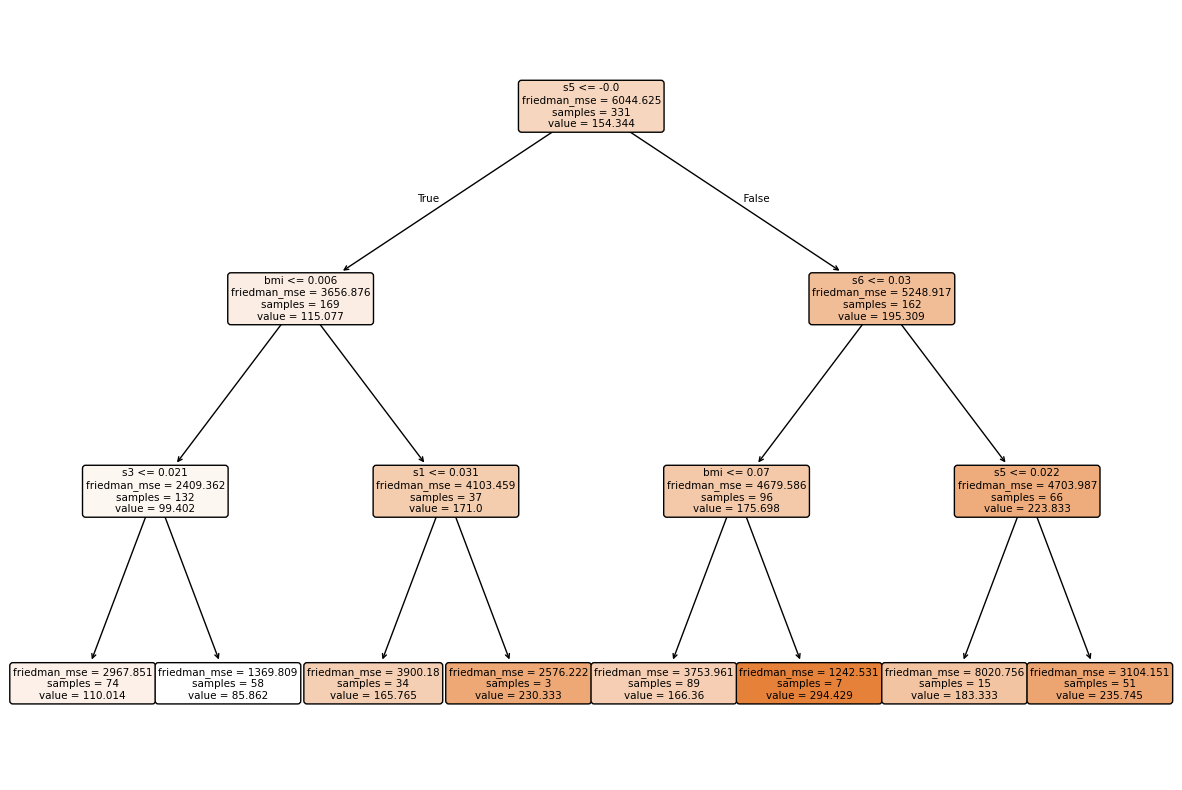

In [35]:
plt.figure(figsize=(15, 10))
tree.plot_tree(selected_model, feature_names=x.columns, filled=True, rounded=True)

In [36]:
# calculate the score of the selected model

print(r2_score(y_test, selected_model.predict(x_test)))

0.4469638160763505
